In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Define file paths
# Assuming the notebook is in 'detect_similarity' folder and files are relative to project root
datasets_path = '../datasets.csv'
results_path = '../detectability/detection_results.csv'
similarity_path = '../cosine-similarity/essay_similarity_results.xlsx'

# Load datasets
try:
    df_datasets = pd.read_csv(datasets_path)
    df_results = pd.read_csv(results_path)
    # Read similarity results
    df_similarity = pd.read_excel(similarity_path)
    
    print("Datasets loaded successfully.")
    print(f"Datasets shape: {df_datasets.shape}")
    print(f"Results shape: {df_results.shape}")
    print(f"Similarity shape: {df_similarity.shape}")

except FileNotFoundError as e:
    print(f"Error loading files: {e}")
    # For demonstration purposes if files are missing in this environment
    df_datasets = pd.DataFrame()
    df_results = pd.DataFrame()
    df_similarity = pd.DataFrame()
except ImportError as e:
    print(f"ImportError: {e}. You may need to install openpyxl: pip install openpyxl")
    df_similarity = pd.DataFrame()

Datasets loaded successfully.
Datasets shape: (180, 6)
Results shape: (180, 10)
Similarity shape: (179, 9)


In [17]:
# Merge datasets
# Identify common columns for merging
common_cols = ['topic', 'length', 'AI_model', 'humanizer']

# Convert 'length' column in df_similarity from object to int64 to match df_datasets
length_mapping = {'Short': 1, 'Medium': 2, 'Long': 3}
df_similarity['length'] = df_similarity['length'].map(length_mapping)

# Perform inner join to keep only records present in both datasets and similarity results
# First merge original dataset with detection results
df_merged_1 = pd.merge(df_datasets, df_results, on=common_cols, how='inner')

# Then merge with similarity results
# Note: Ensure columns in common_cols exist in df_similarity and have matching types
df_joined = pd.merge(df_merged_1, df_similarity, on=common_cols, how='inner')

print("Final Joined Dataset Shape:", df_joined.shape)
display(df_joined.head())

# Save joined dataset if needed
# df_joined.to_csv('joined_dataset_full.csv', index=False)

Final Joined Dataset Shape: (179, 17)


,topic,length,AI_model,humanizer,AI_essay_x,humanized_essay_x,copyleaks_AI,copyleaks_humanized,zerogpt_AI,zerogpt_humanized,sapling_AI,sapling_humanized,AI_essay_y,humanized_essay_y,TF-IDF,SBERT,Nemotron
0,1,1,gemini2.5pro,AIHumanizer,The integration of social media into the lives...,The way social media has woven itself into the...,100.0,100.0,100.0,100.00,99.997658,99.995351,The integration of social media into the lives...,The way social media has woven itself into the...,0.359997,0.850309,0.907571
1,1,1,gemini2.5pro,Grammarly,The integration of social media into the lives...,Social media has become a big part of young pe...,100.0,100.0,100.0,100.00,99.997658,99.996127,The integration of social media into the lives...,Social media has become a big part of young pe...,0.336786,0.754118,0.848066
2,1,1,gemini2.5pro,HumanizeAI,The integration of social media into the lives...,The penetration of social media into the lives...,100.0,0.0,100.0,0.00,99.997658,99.843932,The integration of social media into the lives...,The penetration of social media into the lives...,0.502740,0.915031,0.934771
3,1,1,gemini2.5pro,Quillbot,The integration of social media into the lives...,Social media's introduction into young people'...,100.0,100.0,100.0,64.63,99.997658,30.721407,The integration of social media into the lives...,Social media's introduction into young people'...,0.505379,0.930350,0.936948
4,1,1,gemini2.5pro,UndetectableAI,The integration of social media into the lives...,Young people face a harmful environment throug...,100.0,0.0,100.0,0.00,99.997658,99.351209,The integration of social media into the lives...,Young people face a harmful environment throug...,0.428381,0.850842,0.844359


Using detection columns: ['copyleaks_humanized', 'zerogpt_humanized', 'sapling_humanized']
Using similarity columns: ['TF-IDF', 'SBERT', 'Nemotron']


,copyleaks_humanized,zerogpt_humanized,sapling_humanized
TF-IDF,0.063991,0.194758,0.044074
SBERT,0.171991,0.262414,0.105725
Nemotron,0.384101,0.529899,0.241108


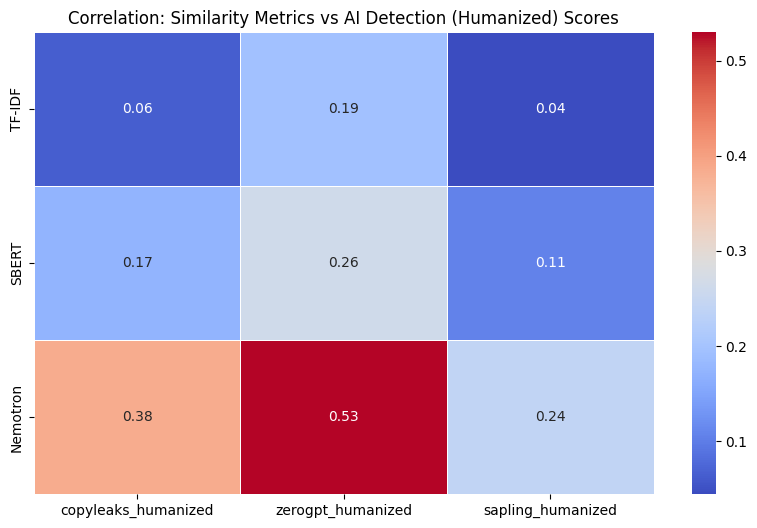

In [18]:
# Calculate Correlation
# Define functionality columns we are interested in from detection results
# Focusing only on _humanized columns as requested earlier
detection_cols = [
    'copyleaks_humanized',
    'zerogpt_humanized',
    'sapling_humanized'
]

# Identify numeric columns from similarity results (excluding common identifying cols)
similarity_cols = [col for col in df_similarity.columns if col not in common_cols and pd.api.types.is_numeric_dtype(df_similarity[col])]

print(f"Using detection columns: {detection_cols}")
print(f"Using similarity columns: {similarity_cols}")

# Combine for correlation analysis
correlation_cols = detection_cols + similarity_cols

# Check which columns are actually present in df_joined
present_cols = [col for col in correlation_cols if col in df_joined.columns]

# Calculate correlation matrix
corr_matrix = df_joined[present_cols].corr()

# Filter the correlation matrix to show only Similarity vs Detection
# Rows: Similarity Metrics, Columns: Detection Metrics (Humanized)
valid_sim_cols = [c for c in similarity_cols if c in corr_matrix.index]
valid_det_cols = [c for c in detection_cols if c in corr_matrix.columns]

if valid_sim_cols and valid_det_cols:
    heatmap_data = corr_matrix.loc[valid_sim_cols, valid_det_cols]
    
    # Display correlation subset
    display(heatmap_data)

    # Plot Heatmap
    plt.figure(figsize=(10, 6))
    sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
    plt.title('Correlation: Similarity Metrics vs AI Detection (Humanized) Scores')
    plt.show()
else:
    print("Could not generate specific heatmap due to missing columns in the joined dataset.")
    print("Full correlation matrix:")
    display(corr_matrix)